# Lab 3: Embedding Visualisation
*   **Course**: CM52065 Natural Language Processing
*   **Author**: Dr. Andrew Barnes

## Overview
In this week's lab you will be using common NLP libraries to implement, visualise and then apply word embeddings to a multilingual dataset.

The learning objectives for this lab are as follows:

1. Apply static embeddings using Word2Vec.
2. Apply contextual embeddings.
3. Visualise and compare embeddings using PCA.

To achieve these objectives we will be using a corpus of English and Spanish sentences to illustrate multilingual approaches.

## Packages

To get started we need to install a number of additional NLP packages, notably gensim and allennlp.

In [ ]:
!pip install gensim
!pip install gensim transformers torch sentencepiece


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.1 MB/s eta 0:00:00


In [ ]:
!python -m spacy download xx_ent_wiki_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 68.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('xx_ent_wiki_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Dataset

The dataset provided for this lab contains English to Spanish sentence pairs.

### 1.1 Loading the dataset
Ensure the `eng_esp.tsv` file has been uploaded to Colab or is available locally then run the code below.

> NOTE: I have limited the dataset to 2500 sentences for illustration purpposes, if you're confident with this lab feel free to expand this to 10,000 or more!

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_name = '/content/drive/MyDrive/MSc Advanced Machine Learning/Semester 2/Natural Language Processing/Week 3/eng_esp.tsv'

In [ ]:
import pandas as pd
dataset = pd.read_csv(file_name, sep='\t')[:2500]

In [ ]:
dataset.rename(columns={'1276': 'IdxE', "Let's try something.": 'English', '2481': 'IdxS', '¡Intentemos algo!': 'Spanish'} ,inplace=True)

In [ ]:
dataset

,IdxE,English,IdxS,Spanish
0,1277,I have to go to sleep.,2482,Tengo que irme a dormir.
1,1280,Today is June 18th and it is Muiriel's birthday!,2485,¡Hoy es 18 de junio y es el cumpleaños de Muir...
2,1280,Today is June 18th and it is Muiriel's birthday!,1130137,¡Hoy es el 18 de junio y es el cumpleaños de M...
3,1282,Muiriel is 20 now.,2487,"Ahora, Muiriel tiene 20 años."
4,1282,Muiriel is 20 now.,1130133,Muiriel tiene 20 años ahora.
...,...,...,...,...
2495,17456,I'll lend it to you.,678821,Yo te lo presto.
2496,17460,We'll give you your revenge.,1478574,Te otorgaremos tu venganza.
2497,17462,I'll make you a new suit.,2087270,Le confeccionaré un traje nuevo.
2498,17463,Let me give you a bit of advice.,765251,Déjame darte un consejo.


Let's take a look a couple of the pairs:

In [ ]:
print("=== Sentence 1")
print(f"English: \"{dataset.iloc[0, 1]}\"")
print(f"Spanish: \"{dataset.iloc[0, 3]}\"")

print("\n=== Sentence 5")
print(f"English: \"{dataset.iloc[5, 1]}\"")
print(f"Spanish: \"{dataset.iloc[5, 3]}\"")

=== Sentence 1
English: "I have to go to sleep."
Spanish: "Tengo que irme a dormir."

=== Sentence 5
English: "The password is "Muiriel"."
Spanish: "La contraseña es "Muiriel"."


## Part 1: Preprocessing

Before we can embed the documents we must first preprocess them; however, this time we need to preprocess in multiple languages and so `spacy.load('en')` will not be appropriate as it was trained using English corpora. Instead, we must make use of a multilingual model which included Spanish in its training.

Below, I have provided code to load spacy using a multilingual model alongisde a method which tokenises a given sentence.

In [ ]:
from string import punctuation
from nltk.corpus import stopwords
from tqdm.notebook import tqdm
import spacy

# Load small multilingual model
nlp = spacy.load("xx_ent_wiki_sm")

# Load stop words for English and Spanish
sw_eng, sw_esp = list(stopwords.words('english')), list(stopwords.words('spanish'))

def tokenise(sentence, lan='en'):
  sentence = sentence.translate(str.maketrans('', '', punctuation))             # Punctuation removal
  processed_doc = nlp(sentence)                                                 # Conversion
  tokens = [token.text.lower() for token in processed_doc]                      # Tokenise
  return [w for w in tokens if not w in (sw_eng if (lan == 'en') else sw_esp)]  # Stopword removal

> **Question:** Why does Spanish have a different set of stop words to English?

Using the provided code above complete the method below to tokenise each of the sentences in the corpus (`dataset`) provided.

In [ ]:
def get_tokenised_documents(corpus):
  tokenised_english = []
  tokenised_spanish = []
  ### BEGIN CODE ###
  #print(corpus)
  for idx, rows in corpus.iterrows():
    if rows['English']:
      tokenised_english.append(tokenise(rows['English'], 'en'))
    if rows['Spanish']:
      tokenised_spanish.append(tokenise(rows['Spanish'], 'es'))


  ### END CODE ###
  return tokenised_english, tokenised_spanish

Here is some code to test your method:

In [ ]:
token_english, token_spanish = get_tokenised_documents(dataset)

In [ ]:
if (token_english[50] == ['world', 'werent', 'shape', 'could', 'trust', 'anyone']) and (token_spanish[50] == ['si', 'mundo', 'podría', 'confiar', 'cualquiera']):
  print("Passed!")
else:
  print("Tests failed!")
  print(f"=== English expected: ['world', 'werent', 'shape', 'could', 'trust', 'anyone'], English received: {token_english[50]}")
  print(f"=== Spanish expected: ['si', 'mundo', 'podría', 'confiar', 'cualquiera'], Welsh received: {token_spanish[50]}")

Passed!


## Part 2: Static Embeddings

In this second part we will produce static word embeddings and visualise the outcomes.

### Word2Vec

The `gensim` package provides a nice class `Word2Vec(...)` which allows us to generate and train both types of Word2Vec model. For example, to produce a Word2Vec model approach we can do the following:
```
model = Word2Vec(
  sentences=documents,  # The corpus we are using to train the model.
  vector_size=100,      # Number of hidden nodes.
  window=3,             # Size of the context window.
  min_count=0,          # Allows us to apply frequency pruning.
  sg=0                  # An indicator whether to use CBOW or SkipGram.
)
```

Populate the method below to generate a CBOW Word2Vec model which uses a window size of 1, 100 hidden nodes, and a min_count of 0. If needed you can refer to the documentation [here](https://radimrehurek.com/gensim/models/word2vec.html).

In [ ]:
from gensim.models import Word2Vec

def train_w2v(corpus):
  model = None              # Store your Word2Vec model here
  ### BEGIN CODE
  model = Word2Vec(sentences=corpus, vector_size=100, window=1, min_count=0, sg=0)
  ### END CODE
  return model

Using your method above create a Word2Vec model for both English and Spanish seperately and then embed the documents contained in the dataset using the function provided.

In [ ]:
def generate_embeddings(model, corpus):
  """ This method generates embeddings using the given Word2Vec model and corpus """
  embeddings = []
  for sentence in corpus:
    embedding = []
    for word in sentence:
      embedding.append(model.wv[word])
    embeddings.append(embedding)
  return embeddings

### BEGIN CODE

eng_model = train_w2v(token_english)
esp_model = train_w2v(token_spanish)


esp_embeddings = generate_embeddings(esp_model, token_spanish)
eng_embeddings = generate_embeddings(eng_model, token_english)
### END CODE

Test your code below:

In [ ]:
if len(token_english[200]) == len(eng_embeddings[200]):
  print("Passed!")
else:
  print(f"Failed! Expected {len(token_english[200])} embeddings, received {len(eng_embeddings[200])}.")

Passed!


### Word Similarity
Awesome work! We have now embedded our English and Spanish corpora and now we will explore these embeddings further.

To start, let's use some built-in functions of the Word2Vec models we trained, specifically we will use the following functions:
+ Check the similarity between two words. `model.wv.similarity(x, y)`
+ Retrieve the `n` most similar words to a given word. `model.wv.most_similar(x, topn=z)`
+ Compute language arithmetic based on learnt vocabulary. `model.wv.most_similar(positive=[x, y], negative=[z], topn=z)`

To aid in using these I have provided the vocabularies for both models below along with a quick function to check if a word exists in each. You are welcome to try tokens not in the vocabulary but you might not get the result you expect...

In [ ]:
word_to_check = "model"
if (word_to_check in eng_model.wv.key_to_index):
  print("Word exists!")
else:
  print("Word does not exist!")

print("English Model Vocabulary:")
print({x for y in token_english for x in y})

print("\n")

word_to_check = "compañía"
if (word_to_check in esp_model.wv.key_to_index):
  print("Word exists!")
else:
  print("Word does not exist!")

print("Spanish Model Vocabulary:")
print({x for y in token_spanish for x in y})

Word exists!
English Model Vocabulary:
{'sweet', 'couples', 'pull', 'point', 'trying', 'juice', 'whomever', 'left', 'led', 'chatting', 'instructions', 'unsuitable', 'continue', 'glass', 'bad', 'identical', 'dial', 'silly', 'remarkable', 'drinking', 'study', 'sits', 'good', 'executives', 'knees', 'referring', 'conversation', 'wait', 'dead', 'universe', 'want', 'lyrics', 'bag', 'rice', 'baffled', 'foreign', 'learning', 'oaken', 'siblings', 'yet', 'possible', 'let', 'data', 'ability', 'say', 'everything', 'freedom', 'useless', 'relationship', 'day', 'side', 'mistakes', 'reading', 'due', 'rare', 'heirless', 'work', 'fine', 'moving', 'sounds', 'little', 'subjects', 'exact', 'eyes', 'answered', 'friends', 'mere', 'condoned', 'killed', 'daughter', 'solid', 'fiftytwo', 'read', 'sleeping', 'desired', 'passion', 'comes', 'swim', 'facts', 'smart', 'textbook', 'stocking', 'weaknesses', 'minutes', 'line', 'skin', 'last', 'moon', 'regret', 'irregular', 'tap', 'problem', 'therefore', 'teacher', 'murd

To start, use the `eng_model.wv.similarity(w1, w2)` to compare the similarities between these word pairs:
+ love & happy
+ water & ice
+ teacher & engineer

In [ ]:
### START CODE
print(eng_model.wv.similarity('love', 'happy'))
print(eng_model.wv.similarity('water', 'ice'))
print(eng_model.wv.similarity('teacher', 'engineer'))

### END CODE

0.14387816
0.032386586
-0.12545599


Next, using the `.most_similar(positive=w1, topn=z)`, here `w1` is the word you find to find similar words to and `topn` is the number of most similar words you'd like to return.

Find the 3 most similar words in the Spanish corpus to:
+ juzgar (judge)
+ telefónico (telephone)
+ sol (sun)

(Feel free to use Google Translate to translate the results!)

In [ ]:
### START CODE
print(esp_model.wv.most_similar(positive='juzgar', topn=3))
print(esp_model.wv.most_similar(positive='telefónico', topn=3))
print(esp_model.wv.most_similar(positive='sol', topn=3))
### END CODE

[('pasma', 0.34155476093292236), ('debe', 0.33582812547683716), ('prestar', 0.31578561663627625)]
[('corazón', 0.40503841638565063), ('cortado', 0.35685691237449646), ('defenderla', 0.340695321559906)]
[('aliento', 0.30775752663612366), ('insulto', 0.29986828565597534), ('revisar', 0.29658806324005127)]


Hopefully you also notice that the 'most similar' words appear to be very strange!

> **Question:** Why do you believe the 'most similar' words are odd in comparison to what you may expect?

### Visualising Embeddings

Quantifying the similarity between word embeddings is great, but sometimes it is good to see what's happening graphically.

Unfortunately our word embeddings have 100 dimensions and so visualising the raw data will be practically impossible, instead we will use a decomposition technique called PCA to reduce the 100 dimensions down to 2.

You do not need to know how PCA words for this course, but if you'd like to find out more you can check out this fantastic [StatQuest Video](https://www.youtube.com/watch?v=FgakZw6K1QQ).

Let's get started, first we need to extract the embeddings for each word we wish to plot. In the space below ccreate a list of word embeddings for the following words:
+ love
+ happy
+ water
+ ice
+ angry

In [ ]:
words = ['love', 'happy', 'water', 'ice', 'angry']

In [ ]:
### BEGIN CODE
vectors = [eng_model.wv['love'], eng_model.wv['happy'], eng_model.wv['water'], eng_model.wv['ice'], eng_model.wv['angry']]
### END CODE

Next, we need to create the PCA model which we will use to decompose our embeddings (the code is provided for you).

In [ ]:
from sklearn.decomposition import PCA
decomposed_words = PCA(n_components=2).fit_transform(vectors) # n_components is the number of resulting dimensions

Finally, we can plot our decomposed word embeddings on a figure.

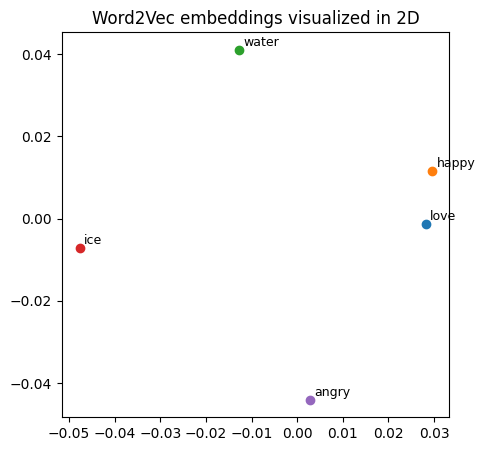

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
for i, word in enumerate(words):
    x, y = decomposed_words[i]
    plt.scatter(x, y)
    plt.text(x+0.001, y+0.001, word, fontsize=9)
plt.title("Word2Vec embeddings visualized in 2D")
plt.show()

Hopefully, what you see above is that happy & love are the closes words, angry is on the same 'side' as them but water and ice are seperate.

### Extra: Experiment Time

Now you've embedded, visualised and compared words using static embeddings take some time to explore the parameters of the Word2Vec class and consider the following questions:
> **Question:** What happens when you change to a skip-gram method?

> **Question:** How does the window size impact the results?

> **Question:** The number of hidden nodes indicates the size of the embedding, what happens when you change this up or down?

## Part 3: Contextual Embeddings

Moving onto contextual embeddings, this time we will use pre-trained BERT weights to create embeddings for the English corpus.

> Note: As we are comparing embeddings in this lab we do not have a downstream task in which to train the task-specific parameters, if this is something you'd like to try, at the end of this lab there is an extension task you may complete.

To do this, we will be using `transformers` a module which gives us BERT without the need for us to build it from scratch, I have provided the code below to load an BERT model and embed the English corpus.

Be warned, this might take a while! Whilst it's computing, consider the following:

> **Question:** Why would we use pretrained weights?

In [ ]:
from transformers import BertTokenizer, BertModel
import torch

In [ ]:
tokeniser = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Let's get our embeddings, this will take a while! Feel free to reduce the size of the corpus when trialling this.

In [ ]:
def generate_bert_embeddings(t, m, corpus):
  """ This method generates BERT embeddings using the given Word2Vec model and corpus """
  word_embeddings = []
  sentence_embeddings = []
  for sentence in tqdm(corpus):
    tokenised = t(' '.join(sentence), return_tensors="pt")
    embedding = m(**tokenised)
    word_embeddings.append(embedding.last_hidden_state.detach().numpy())
    sentence_embeddings.append(embedding.pooler_output.flatten())
  return word_embeddings, sentence_embeddings

# Generate embeddings
eng_embeddings, eng_sent_embeddings = generate_bert_embeddings(tokeniser, model, token_english[:10])


  0%|          | 0/10 [00:00<?, ?it/s]

We now have two sets of embeddings, the first matrix `eng_embeddings` contains embeddings for each word in each document, `eng_sent_embeddings` contains a single embedding for each sentence based on the final activation from the transformer.

### Word Similarity
Now you have an ELMo model and a method for generating embeddings we can now compare the contextualised embeddings with the static embeddings we generated earlier.

To do this, retrieve the static English embeddings and contextualised English embeddings for the following words (the same words as earlier):
+ love
+ happy
+ water
+ ice
+ angry

In [ ]:
words = ['love', 'happy', 'water', 'ice', 'angry']
static_embeddings = [eng_model.wv[word] for word in words]
contextual_embeddings, _ = generate_bert_embeddings(tokeniser, model, words)

  0%|          | 0/5 [00:00<?, ?it/s]

Now let's compare the similarity between word pairs for both static and contextual embeddings but this time using the Cosine Similarity rather than the built in functions in Word2Vec.

To start, we will cheat slightly and use sklearn to fast track a cosine similarity function:

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

Using the cosine_similarity method, calculate the similarity between the following word pairs for both static and contextual embeddings:

+ love & happy
+ love & anger
+ water & ice

You might get a warning to reshape your embeddings, simply add a `.reshape(1, -1)` following the embedding vector for example:
`static_embeddings[0].reshape(1, -1)`.

An example has been provided.

In [ ]:
print(cosine_similarity(static_embeddings[0].reshape(1, -1), static_embeddings[1].reshape(1, -1)))
print(cosine_similarity(contextual_embeddings[0][0][0, :].reshape(1, -1), contextual_embeddings[0][0][1, :].reshape(1, -1)))

### BEGIN CODE

print(cosine_similarity(static_embeddings[0].reshape(1, -1), static_embeddings[4].reshape(1, -1)))
print(cosine_similarity(contextual_embeddings[0][0][0, :].reshape(1, -1), contextual_embeddings[0][0][4, :].reshape(1, -1)))

print(cosine_similarity(static_embeddings[2].reshape(1, -1), static_embeddings[3].reshape(1, -1)))
print(cosine_similarity(contextual_embeddings[0][0][2, :].reshape(1, -1), contextual_embeddings[0][0][3, :].reshape(1, -1)))

### END CODE

[[0.14387816]]
[[0.55477035]]
[[-0.00078989]]
[[0.19128278]]
[[0.03238658]]
[[0.8478862]]


> **Question:** What differences and similarities do you notice?

> **Question:** Why do you think these differences appear?

### Extra: Visualise Contextual Embeddings

Using the contextual embedding model you created above you an now try plotting different words using the same PCA approach we introduced earlier.

The benefit of the pre-trained weights approach is that you will be able to access far more words.

> **Question:** Plot king, queen, woman, man, what do you notice?

## Optional Exercise (Challenging)

If you're feeling confident you can try applying ELMo embeddings to the sentiment analysis task from last week. You will need the support of the allennlp documentation. If you want to instead try a simpler problem, try using Word2Vec first then try ELMo. Remember for ELMo you should also train the task-specific parameters!

## Wrap-up
Well done on finishing up this week's lab! I hope you were able to practice what we learnt in the lectures and now have a better understanding of how word embeddings are used to relate words together.

Next week we will be looking at how we can use classical approaches to further enhance our understanding of the words in corpora.